Controllo (Cont): Rete decisionale e di pianificazione. Ci aiuta a ragionare, prendere decisioni e risolvere compiti complessi.

Attenzione Dorsale (DorsAttn): Rete della concentrazione. Serve per focalizzare volontariamente l'attenzione su qualcosa nel mondo esterno 

Visiva (Vis): Rete della vista. Si occupa semplicemente di elaborare le immagini e tutto ciò che vediamo.

Salienza (SalVentAttn): Rete "allarme". Scatta in automatico per catturare la nostra attenzione quando succede qualcosa di improvviso o importante nell'ambiente.

Default Mode (Default): Rete del pensiero interno. Si accende quando siamo a riposo, sogniamo a occhi aperti, ricordiamo il passato o la mente vaga senza uno scopo preciso.

In [1]:
# Standard Imports
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import zscore

# Utils
from utils.display import loadAndDisplay, displayGroupOfSlices
from utils.similarities import *
# System Paths
from config import *

In [2]:
out_dir = Path("data/part2")
out_4d_mni     = out_dir / "fmri_in_MNI_4D.nii.gz"

norm_fmri_dict = loadAndDisplay(str(out_4d_mni), "FMRI NORMALIZED", print_summary=True)
atlas_dict     = loadAndDisplay(ATLAS_PATH, "ATLAS", print_summary=True)
mni_dict       = loadAndDisplay(MNI_PATH, "MNI", print_summary=False)

regions_csv = pd.read_csv(REGIONS_CSV_PATH)
df = pd.DataFrame(regions_csv)


INFORMATION ABOUT FMRI NORMALIZED NIFTI FILE:

----------------------------------------------------------------------------------------------------
Type of variable nii_img: <class 'nibabel.nifti1.Nifti1Image'>
Type of variable nii_hdr: <class 'nibabel.nifti1.Nifti1Header'>
Shape of the NIfTI image: (91, 109, 91, 200)
Dimensions of the NIfTI image: [  4  91 109  91]
Dimensions of NIfTI img data: (91, 109, 91, 200)
Voxel size (mm): (2.0, 2.0, 2.0, 3.56)

INFORMATION ABOUT ATLAS NIFTI FILE:

----------------------------------------------------------------------------------------------------
Type of variable nii_img: <class 'nibabel.nifti1.Nifti1Image'>
Type of variable nii_hdr: <class 'nibabel.nifti1.Nifti1Header'>
Shape of the NIfTI image: (91, 109, 91)
Dimensions of the NIfTI image: [  3  91 109  91]
Dimensions of NIfTI img data: (91, 109, 91)
Voxel size (mm): (2.0, 2.0, 2.0)


### Some visualization to compare norm_fmri and the mni space

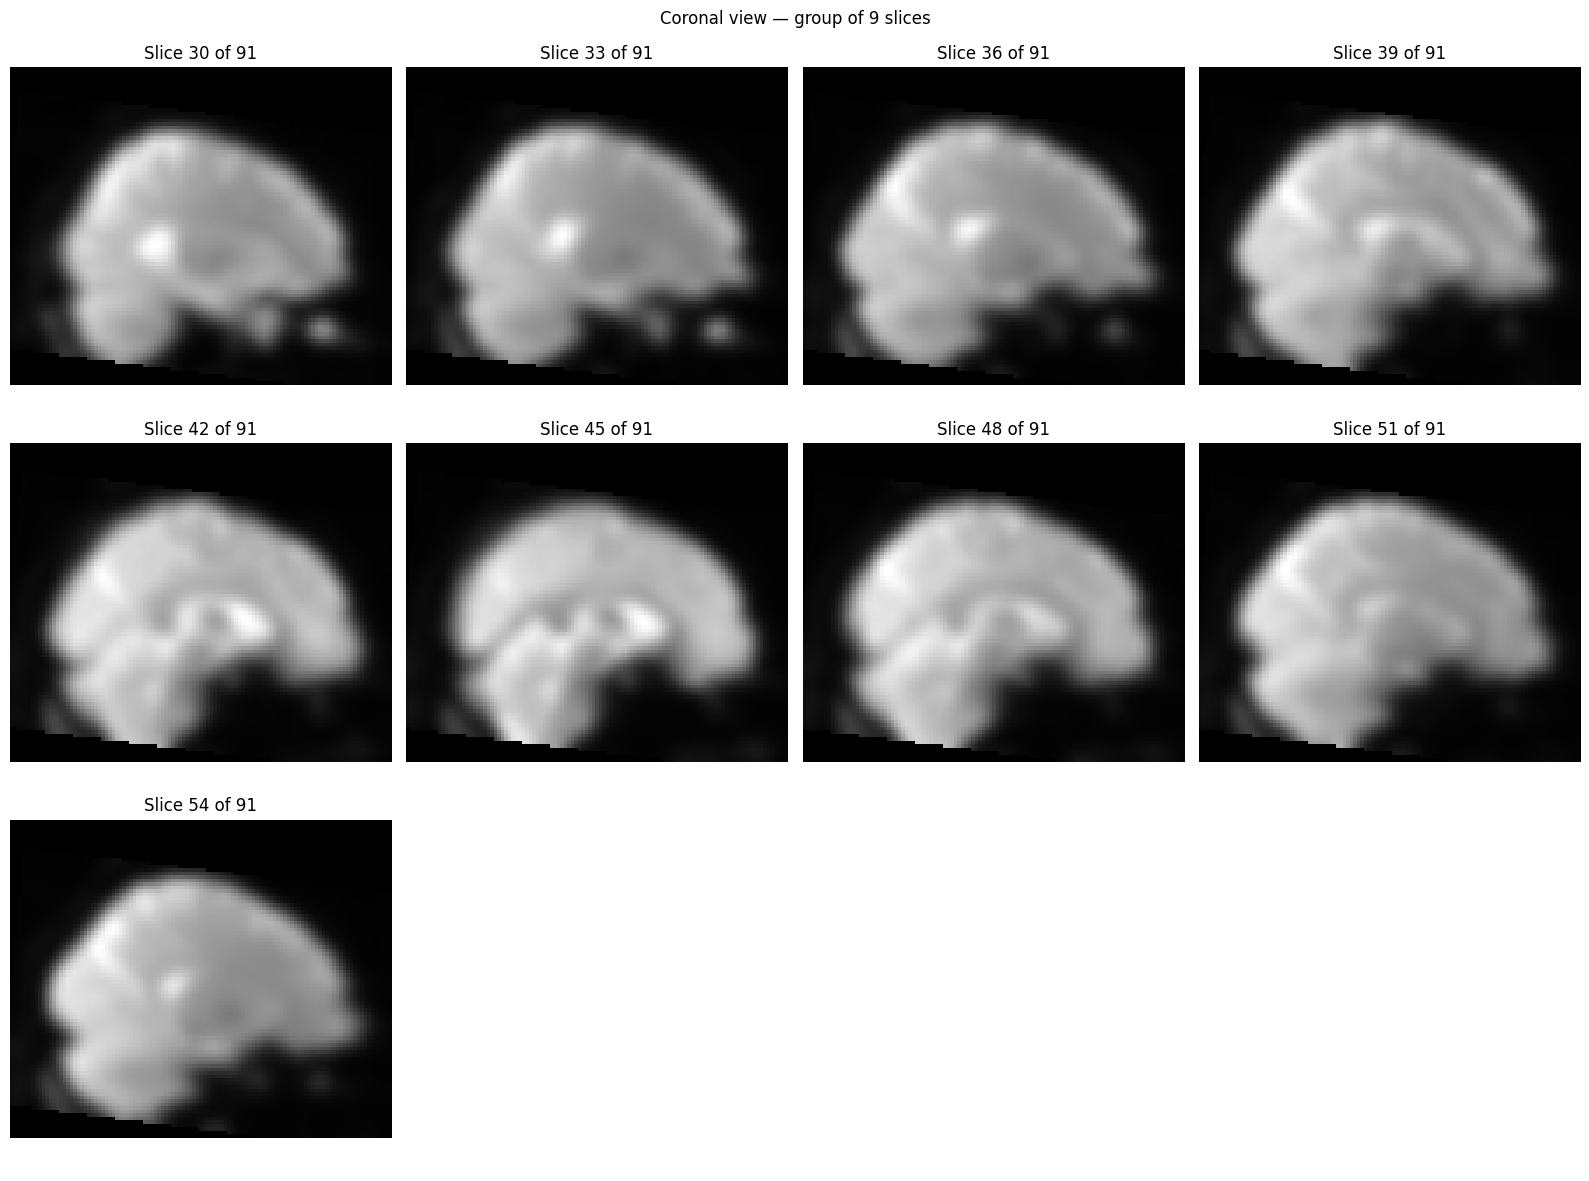

In [3]:
displayGroupOfSlices(norm_fmri_dict['data'], 9, starting_idx=30, disp_step=3, axis='coronal',time_instant=50)

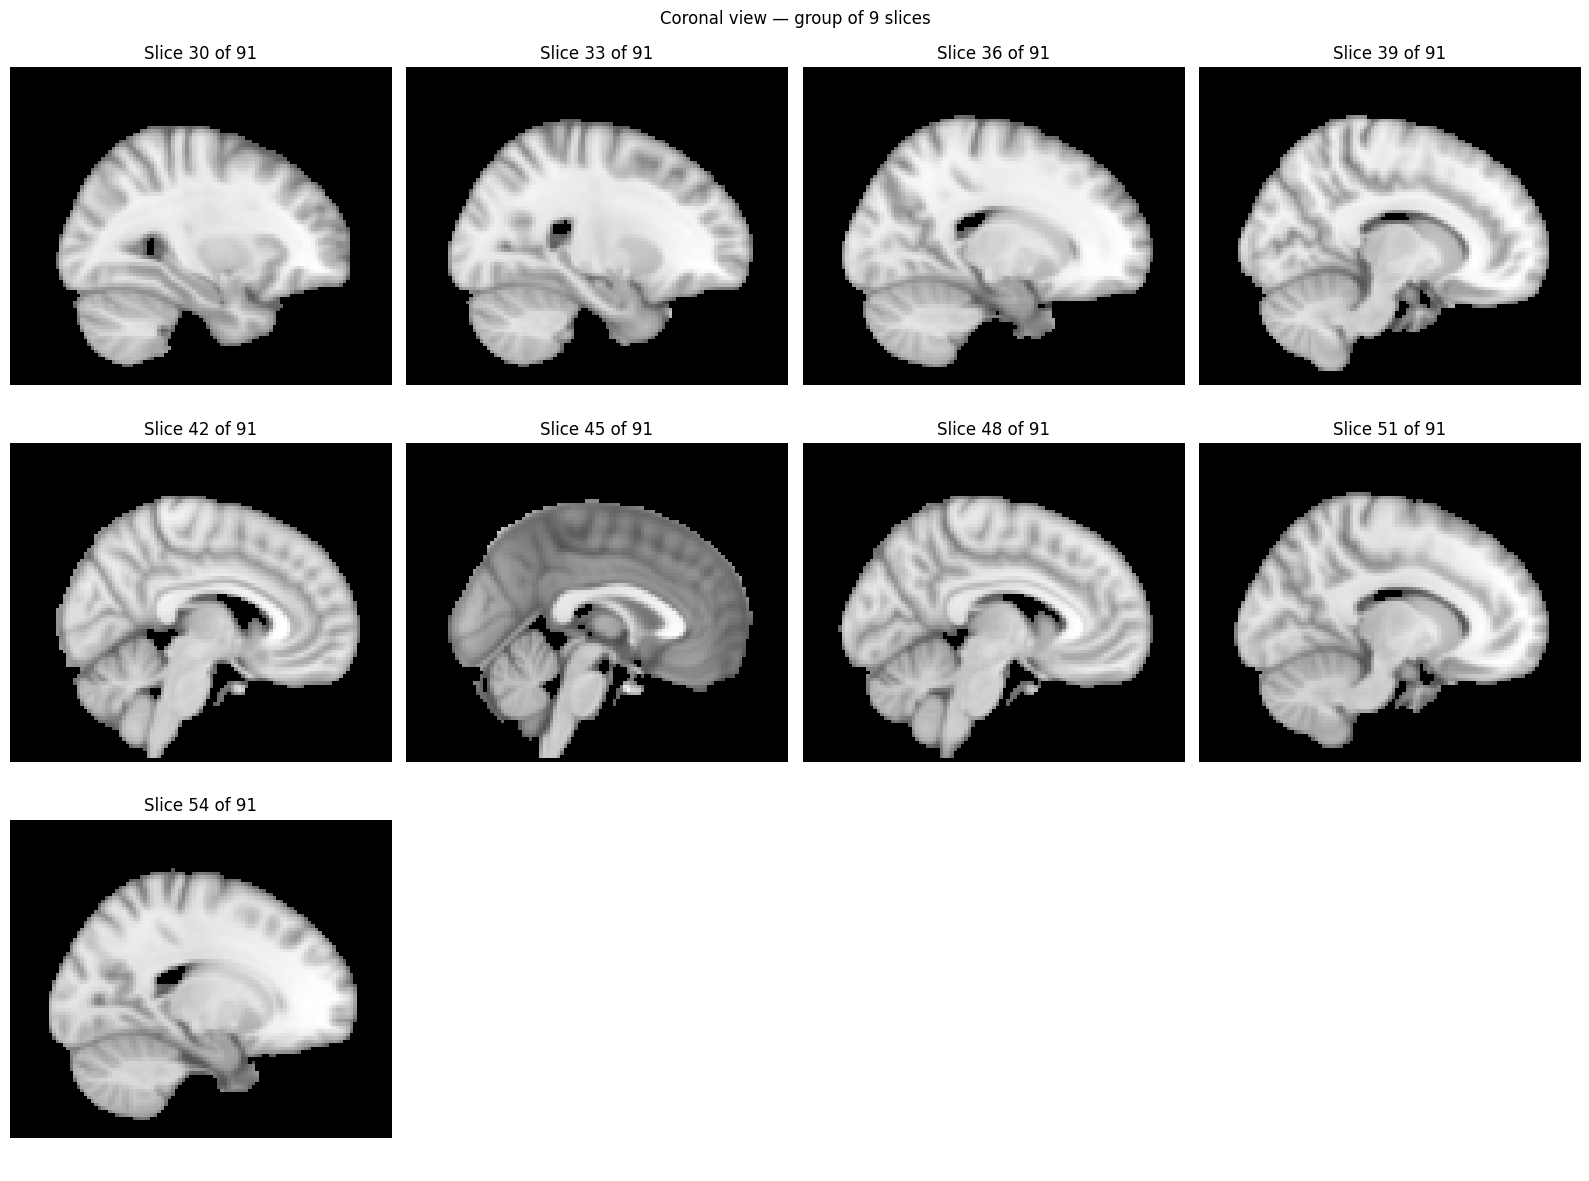

In [4]:
displayGroupOfSlices(mni_dict['data'], 9, starting_idx=30, disp_step=3, axis='coronal')

### Step by Step - Compute the mean fMRI time series for each brain parcel
1) Create a matrix of zeros of shape 200 x 200 that will contain the final result
2) Do a for cycle, that slides over each label
3) For each label, extract the mask with valid pixels and then use it to extract the correct data from the norm_fmri data
4) Save the data in the correct position of the time_series matrix
5) Save the result

In [5]:
num_time_pts = norm_fmri_dict['data'].shape[3]
num_labels = 200

# 1)
time_series = np.zeros((num_time_pts, num_labels))

# 2)
for label_idx in range(1, num_labels + 1):
    # 3)
    mask = (atlas_dict['data'] == label_idx)
    if np.any(mask):
        # 4)
        time_series[:, label_idx - 1] = norm_fmri_dict['data'][mask, :].mean(axis=0) # Because applying the mask results in a matrix of shape 2

# 5)
np.save("data/part3/time_series.npy", time_series)
print("Shape time series estratte:", time_series.shape)  # (T, 200)

Shape time series estratte: (200, 200)


### For each pair of signals quantify their similarity, for example relying on Pearson correlation coefficient or on some distance measures.
General thoughts:
cosa vorrei fare: confrontare + metodi di similarità, potrei partire confrontando direttamente le matrici, oppure confrontando i primi 10 valori + alti con
entrambi i metodi oppurre contando le occorrenze e vedere se sono coerenti tra più metodi
magari fare anche una funzione che prende in input una coppia di label o una sola label e mi estrae fuori il nome completo della regione cerebrale

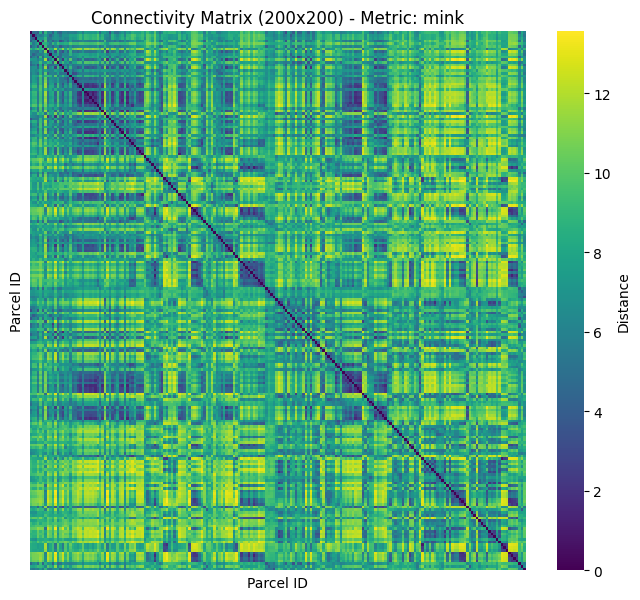

In [6]:
# This is necessary because some similarity measures are computed from the magnitude of the signals. It's like computing a MSE that 
# depends on the magnitude, the normalization collapse everything in a defined interval of [-1,1]
time_series_z = zscore(time_series, axis=0)

# These are the methods that I want to try 
# This is the link at the source I used to find other methods https://pmc.ncbi.nlm.nih.gov/articles/PMC7671987/
methods = ['corr', 'spearman', 'euclidean', 'cheby', 'mink']
matrices = {m: computeSimilarityMatrix(time_series, similarity_measure=m, plot=False) for m in methods}

# Let's plot an example
mat_mink = computeSimilarityMatrix(time_series, similarity_measure='mink', plot=True)

In [7]:
pairs = getTopKPairs(matrices['corr'], k=10)
total_result = []
for pair in pairs:
    region1 = pair[0]
    region2 = pair[1]
    value = pair[2]

    res = {'Region 1:': extractRegionNameFromLabel(region1, df), "Region 2": extractRegionNameFromLabel(region2,df), 'Value': value }
    total_result.append(res)

df_best_similarities = pd.DataFrame(total_result)
display(df_best_similarities)

,Region 1:,Region 2,Value
0,7Networks_LH_SomMot_10,7Networks_LH_SomMot_12,0.992128
1,7Networks_RH_Limbic_OFC_1,7Networks_RH_Default_PFCdPFCm_1,0.991271
2,7Networks_LH_SalVentAttn_PFCl_1,7Networks_LH_Default_PFC_9,0.990548
3,7Networks_LH_SomMot_9,7Networks_LH_SomMot_12,0.987904
4,7Networks_LH_SomMot_9,7Networks_LH_SomMot_10,0.987328
5,7Networks_LH_SalVentAttn_PFCl_1,7Networks_LH_Cont_PFCl_3,0.983693
6,7Networks_LH_SomMot_11,7Networks_LH_SomMot_13,0.983583
7,7Networks_LH_SalVentAttn_ParOper_3,7Networks_LH_Cont_Par_1,0.983158
8,7Networks_LH_Default_PFC_9,7Networks_RH_Default_PFCdPFCm_5,0.983025
9,7Networks_RH_SomMot_18,7Networks_RH_SomMot_19,0.982894


### Usefull source
Rank Correlation (Spearman's ρ or Kendall's τ): Extracts the upper or lower triangles of both matrices as vectors and computes a rank correlation. This tests if pairs of items maintain the same relative similarity order even if absolute values differ. [1] (https://jinhyuncheong.com/jekyll/update/2021/12/20/CorrelationMatrixSimilarity.html)

In [8]:
summary = compareSimilarityMethods(matrices, df, top_k=3)
pd.set_option('display.max_colwidth', None)
display(summary)

,Method,Type,Mean,Std,Min,Max,Global Agreement vs Pearson (Spearman ρ),Top-3 Functional Pairs,Overlap Top-3 w/ Pearson (Jaccard)
0,corr,Correlazione,0.165,0.432,-0.977,0.992,1.000,7Networks_LH_SomMot_10 <-> 7Networks_LH_SomMot_12 (0.99); 7Networks_RH_Limbic_OFC_1 <-> 7Networks_RH_Default_PFCdPFCm_1 (0.99); 7Networks_LH_SalVentAttn_PFCl_1 <-> 7Networks_LH_Default_PFC_9 (0.99),3/3 (100.0%)
1,spearman,Correlazione,0.172,0.408,-0.939,0.991,0.995,7Networks_LH_SomMot_10 <-> 7Networks_LH_SomMot_12 (0.99); 7Networks_LH_SomMot_9 <-> 7Networks_LH_SomMot_10 (0.99); 7Networks_LH_SomMot_9 <-> 7Networks_LH_SomMot_12 (0.99),1/3 (20.0%)
2,euclidean,Distanza,17.546,5.096,1.774,28.125,-1.000,7Networks_LH_SomMot_10 <-> 7Networks_LH_SomMot_12 (1.77); 7Networks_RH_Limbic_OFC_1 <-> 7Networks_RH_Default_PFCdPFCm_1 (1.87); 7Networks_LH_SalVentAttn_PFCl_1 <-> 7Networks_LH_Default_PFC_9 (1.94),3/3 (100.0%)
3,cheby,Distanza,3.358,0.952,0.312,6.686,-0.887,7Networks_RH_Limbic_OFC_1 <-> 7Networks_RH_Default_PFCdPFCm_1 (0.31); 7Networks_LH_SomMot_10 <-> 7Networks_LH_SomMot_12 (0.36); 7Networks_LH_SomMot_9 <-> 7Networks_LH_SomMot_12 (0.43),2/3 (50.0%)
4,mink,Distanza,8.387,2.417,0.879,13.561,-0.997,7Networks_LH_SomMot_10 <-> 7Networks_LH_SomMot_12 (0.88); 7Networks_RH_Limbic_OFC_1 <-> 7Networks_RH_Default_PFCdPFCm_1 (0.88); 7Networks_LH_SalVentAttn_PFCl_1 <-> 7Networks_LH_Default_PFC_9 (0.96),3/3 (100.0%)


### Some explanations
- Correlation and euclidean distance are really bond together, in fact, they represent the same metric but under a different point of view. They have in common all the pairs, and while they also have a global agreement of -1 this is because while the corr is max when corr = 1, the euclidean distance is max when dist = minimum = 0, they are inversaly proportional

- Spearman transform values in a ranking. Region A [10, 12, 100], Region B [10,12,15] lower correlation but the ranking for the two signal is the same so Spearman will be maximum. If we have some noise represented by a spike, for the spearman its the same, but for corr it lower the value

- cheby is the weakest one: measure similarity based on the time instant where the two signal are more far away. It looks for the highest value while doing a difference for each position, differently w.r.t euclidean distance that would average them. --> noise affects largely this measure

# PCA and ICA analysis
Here I apply these two analysis directly on the time series

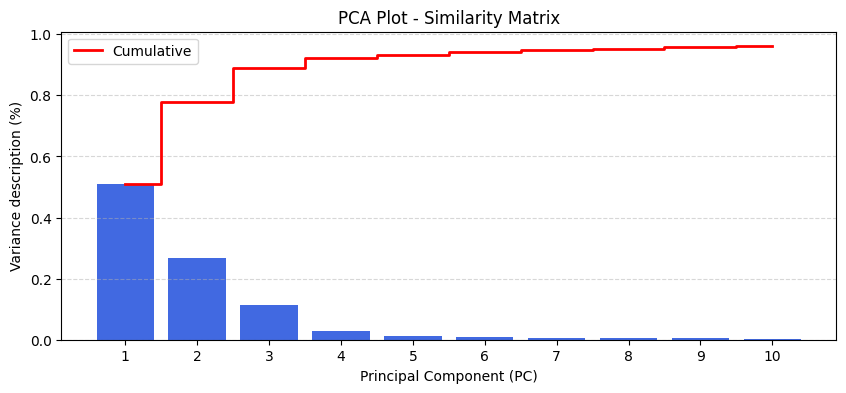

Total variance description (first 4 PC): 92.06%

--- Top 10 Regions associated to PC1) ---


,Parcel_ID,Region Name,Loading_PC1
0,80,7Networks_LH_Default_Par_2,0.2245
1,23,7Networks_LH_SomMot_9,0.2122
2,114,7Networks_RH_Vis_14,0.1980
3,61,7Networks_LH_Cont_Par_1,0.1861
4,11,7Networks_LH_Vis_11,0.1774
5,38,7Networks_LH_DorsAttn_Post_8,0.1703
6,140,7Networks_RH_DorsAttn_Post_6,0.1679
7,135,7Networks_RH_DorsAttn_Post_1,-0.1671
8,132,7Networks_RH_SomMot_17,0.1612
9,143,7Networks_RH_DorsAttn_Post_9,0.1609


In [ ]:
results = pcaAnalysis(time_series, 10, df)
display(results)

### PCA conclusions:
with only four components the loss of variance was only 8%. By using 4 components / 200 we lost a minor part of the dynamic of the signal
- Higher collected variance: default network and somatosensory network representing the global signal, the steady state behavior of the brain is captured

/Users/tommasodelucchi/MasterDegree-Year-1/MedicalImaging/project/.venv/lib/python3.10/site-packages/sklearn/decomposition/_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


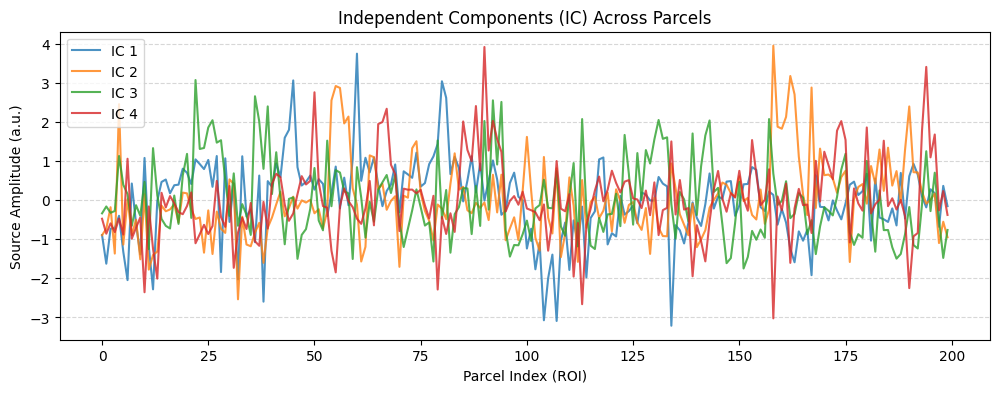


--- Top 10 Regions associated to Independent Component 1 (IC1) ---


,Parcel_ID,Region Name,Weight_IC1
0,61,7Networks_LH_Cont_Par_1,3.7416
1,135,7Networks_RH_DorsAttn_Post_1,-3.2119
2,108,7Networks_RH_Vis_8,-3.0905
3,105,7Networks_RH_Vis_5,-3.0726
4,46,7Networks_LH_SalVentAttn_ParOper_3,3.0581
5,81,7Networks_LH_Default_Par_3,3.0353
6,82,7Networks_LH_Default_Par_4,2.6135
7,39,7Networks_LH_DorsAttn_Post_9,-2.5969
8,13,7Networks_LH_Vis_13,-2.2823
9,7,7Networks_LH_Vis_7,-2.0462


In [ ]:
ica_df = icaAnalysis(time_series.T, 4, df)
display(ica_df)
# per ciascuna sorgente viene assegnato un peso a ciascuna parcel su quanto sta partecipando alla dinamica della sorgente


statistically independent sources are found, the two most important sources are left control network (positive), dorsal attention network (negative). These two sources works in opposition
- Biological independent modules were localized

### ICA conclusions

IC1: osservando i pesi assegnati ai vari network c'è una divisione tra
- 7Networks_LH_Cont_Par_1, 7Networks_LH_SalVentAttn_ParOper_3, 7Networks_LH_Default_Par_3, 7Networks_LH_Default_Par_4

e

- 7Networks_RH_DorsAttn_Post_1, 7Networks_RH_Vis_8, 7Networks_RH_Vis_5, 7Networks_LH_DorsAttn_Post_9, 7Networks_LH_Vis_13, 7Networks_LH_Vis_7

IC1 dimostra che questi due macro network sono indipendenti e quando uno è molto attivo l'altro sarà praticamente nullo. Infatti il primo macrosistema rappresenta il momento in cui l'individuo pianifica...pensa... nel secondo macrosistema invece c'è più la parte sensoriale dominata quindi dalla vista... dalla concentrazione sull'ambiente.... 